# 07 — Comparison & Explainability

Run this **last**, after `00_Preprocessing.ipynb` and all 6 model
notebooks (`01`–`06`). Collects every model's saved results into one
comparison table + plots, then runs SHAP on the best ML model and best
DL model.

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import tensorflow as tf

from utils import PROCESSED_DIR, RESULTS_DIR, MODELS_DIR, PLOTS_DIR, load_all_results

sns.set_theme(style="whitegrid")


## Load All Model Results

In [2]:
all_results = load_all_results()
assert len(all_results) > 0, "No results found in results/ — run notebooks 01-06 first."
print(f"Loaded results for {len(all_results)} models:", [r['Model'] for r in all_results])


Loaded results for 6 models: ['1D CNN', 'Autoencoder+MLP', 'LightGBM', 'MLP', 'Random Forest', 'XGBoost']


## Comparison Table

In [3]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("Confusion Matrix", "history")}
    for r in all_results
])
results_df = results_df.sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df.to_csv(os.path.join(RESULTS_DIR, "comparison_table.csv"), index=False)

display(results_df.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"], cmap="Greens"
))


C:\Users\Sushant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
C:\Users\Sushant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,MCC,Cohen's Kappa,Train Time (s),Prediction Time (s)
0,XGBoost,0.998507,0.755880,0.770644,0.762544,nan,0.995359,0.995358,425.648960,2.054996
1,LightGBM,0.998264,0.759443,0.766337,0.762398,nan,0.994600,0.994600,276.400834,14.775005
2,Random Forest,0.997574,0.724527,0.754886,0.734381,nan,0.992468,0.992463,92.268597,0.778929
3,MLP,0.949218,0.516498,0.838773,0.592310,nan,0.866162,0.858398,50.377780,2.366001
4,Autoencoder+MLP,0.937423,0.462932,0.837416,0.547596,nan,0.841263,0.830114,222.890061,2.202999
5,1D CNN,0.910922,0.379810,0.756120,0.437558,nan,0.780499,0.765473,424.803360,3.779997


## Comparison Bar Charts (all 7 metrics)

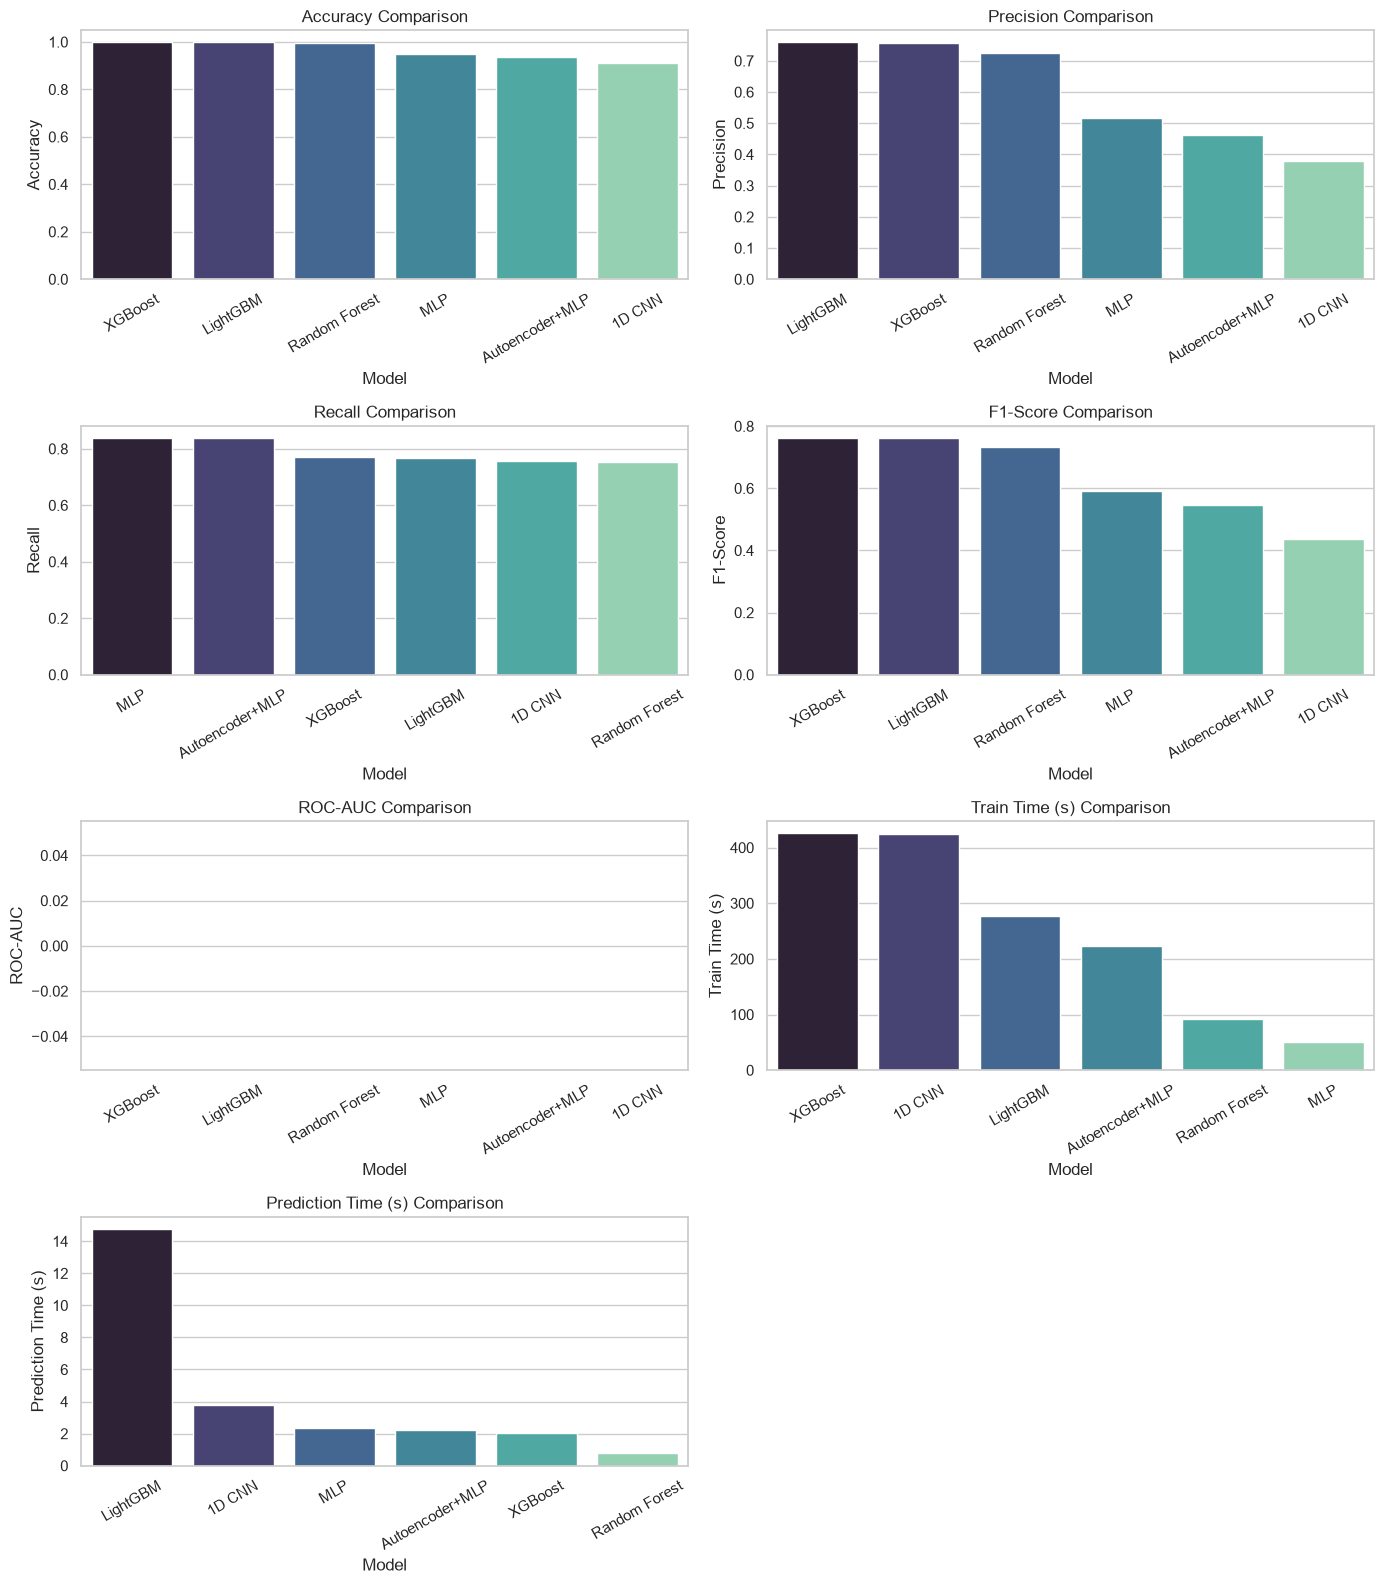

In [4]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC",
                    "Train Time (s)", "Prediction Time (s)"]
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel()
for ax, metric in zip(axes, metrics_to_plot):
    order = results_df.sort_values(metric, ascending=False)
    sns.barplot(data=order, x="Model", y=metric, hue="Model", palette="mako", legend=False, ax=ax)
    ax.set_title(f"{metric} Comparison")
    ax.tick_params(axis="x", rotation=30)
axes[-1].axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "comparison_bar_charts.png"), dpi=150)
plt.show()


## All Confusion Matrices Side-by-Side

C:\Users\Sushant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\utils.py:61: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.draw()
C:\Users\Sushant\AppData\Local\Temp\ipykernel_6352\3567462725.py:18: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig(os.path.join(PLOTS_DIR, "all_confusion_matrices.png"), dpi=150)
C:\Users\Sushant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


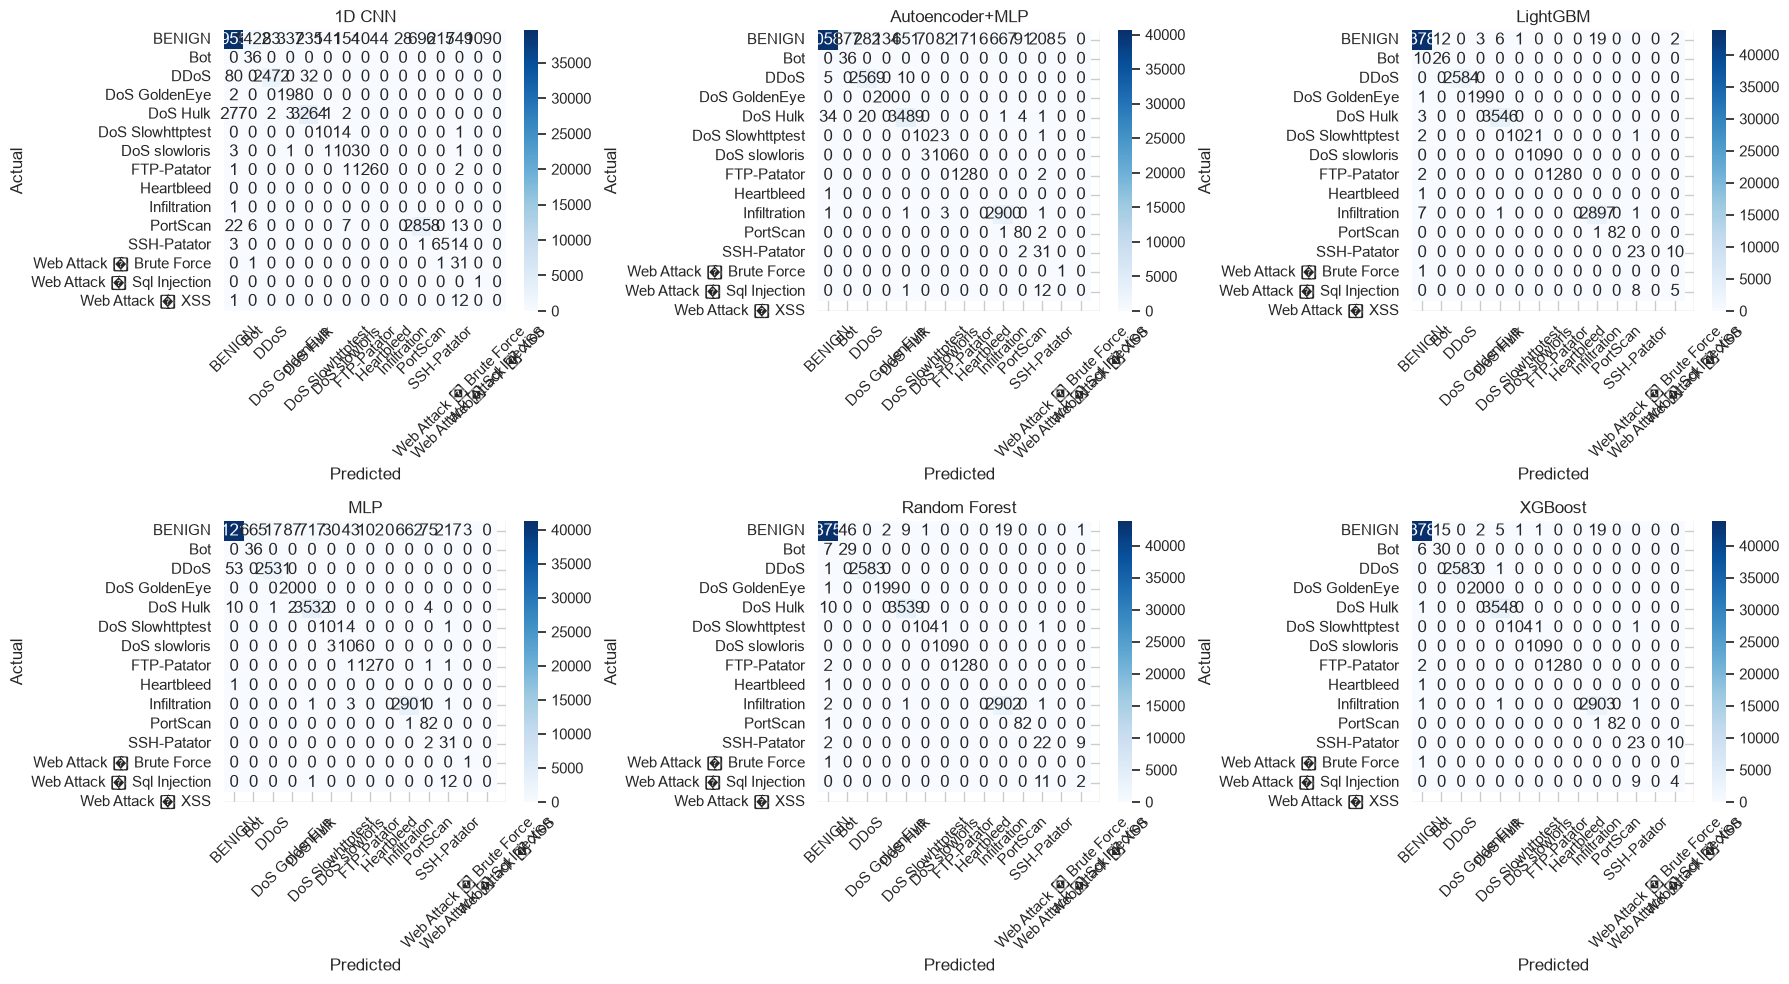

In [5]:
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))

n_models = len(all_results)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
axes = np.array(axes).reshape(-1)
for ax, r in zip(axes, all_results):
    cm = np.array(r["Confusion Matrix"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(r["Model"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.tick_params(axis="x", rotation=45)
for ax in axes[len(all_results):]:
    ax.axis("off")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "all_confusion_matrices.png"), dpi=150)
plt.show()


## Identify Best ML Model and Best DL Model

In [6]:
ML_MODELS = {"Random Forest", "XGBoost", "LightGBM"}
DL_MODELS = {"MLP", "1D CNN", "Autoencoder+MLP"}

ml_results = [r for r in all_results if r["Model"] in ML_MODELS]
dl_results = [r for r in all_results if r["Model"] in DL_MODELS]

best_ml_name = max(ml_results, key=lambda r: r["F1-Score"])["Model"] if ml_results else None
best_dl_name = max(dl_results, key=lambda r: r["F1-Score"])["Model"] if dl_results else None
print(f"Best ML model: {best_ml_name}")
print(f"Best DL model: {best_dl_name}")


Best ML model: XGBoost
Best DL model: MLP


In [7]:
# Identify the single overall best model across all 6 (by F1-Score)
overall_best_row = max(all_results, key=lambda r: r["F1-Score"])
overall_best_name = overall_best_row["Model"]
print(f"Overall best model (all 6): {overall_best_name}  (F1-Score = {overall_best_row['F1-Score']:.4f})")

Overall best model (all 6): XGBoost  (F1-Score = 0.7625)


C:\Users\Sushant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_ranking.py:1364: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\Users\Sushant\AppData\Local\Temp\ipykernel_6352\1658405510.py:49: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Sushant\AppData\Local\Temp\ipykernel_6352\1658405510.py:50: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.savefig(os.path.join(PLOTS_DIR, "roc_curve_overall_best_model.png"), dpi=150)
C:\Users\Sushant\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


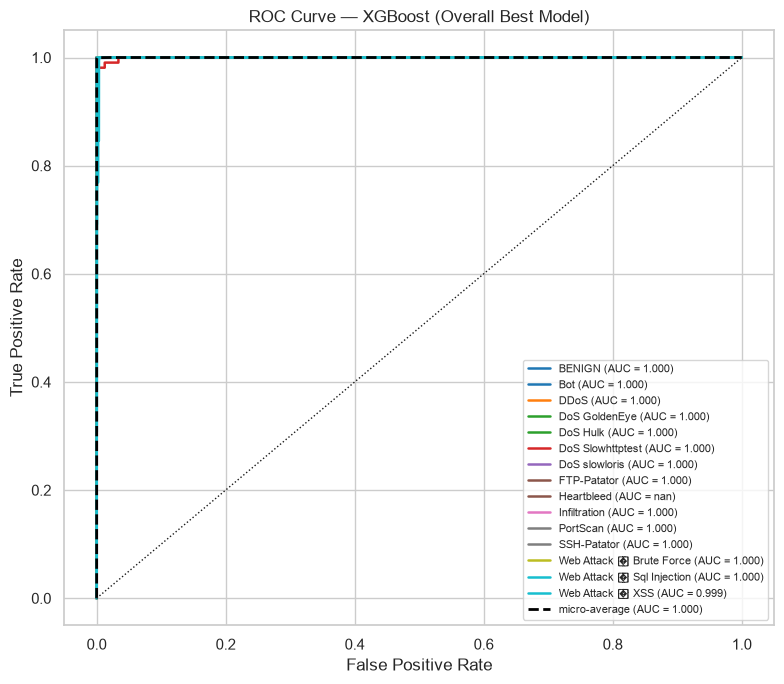

In [8]:
import tensorflow as tf
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

ML_MODEL_FILES = {"Random Forest": "RandomForest.joblib", "XGBoost": "XGBoost.joblib", "LightGBM": "LightGBM.joblib"}
DL_MODEL_FILES = {"MLP": "MLP.keras", "1D CNN": "CNN1D.keras", "Autoencoder+MLP": "AutoencoderMLP_classifier.keras"}

X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
y_test = np.load(os.path.join(PROCESSED_DIR, "y_test.npy"))
class_names = joblib.load(os.path.join(PROCESSED_DIR, "class_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

# Load the overall best model and regenerate its predicted probabilities
if overall_best_name in ML_MODEL_FILES:
    best_overall_model = joblib.load(os.path.join(MODELS_DIR, ML_MODEL_FILES[overall_best_name]))
    y_proba_best = best_overall_model.predict_proba(X_test)
else:
    best_overall_model = tf.keras.models.load_model(os.path.join(MODELS_DIR, DL_MODEL_FILES[overall_best_name]))
    if overall_best_name == "1D CNN":
        X_input = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    elif overall_best_name == "Autoencoder+MLP":
        ae_encoder_for_roc = tf.keras.models.load_model(os.path.join(MODELS_DIR, "AutoencoderMLP_encoder.keras"))
        X_input = ae_encoder_for_roc.predict(X_test, verbose=0)
    else:
        X_input = X_test
    y_proba_best = best_overall_model.predict(X_input, verbose=0)

# One-vs-rest ROC curve per class + micro-average
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))
fpr, tpr, roc_auc_dict = {}, {}, {}
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba_best[:, i])
    roc_auc_dict[i] = auc(fpr[i], tpr[i])
fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_proba_best.ravel())
roc_auc_dict["micro"] = auc(fpr["micro"], tpr["micro"])

plt.figure(figsize=(8, 7))
colors = plt.cm.tab10(np.linspace(0, 1, n_classes))
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=1.8,
             label=f"{class_names[i]} (AUC = {roc_auc_dict[i]:.3f})")
plt.plot(fpr["micro"], tpr["micro"], color="black", linestyle="--", lw=2,
         label=f"micro-average (AUC = {roc_auc_dict['micro']:.3f})")
plt.plot([0, 1], [0, 1], "k:", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {overall_best_name} (Overall Best Model)")
plt.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "roc_curve_overall_best_model.png"), dpi=150)
plt.show()

## Load Data + Best Models for SHAP

In [9]:
X_train_res = np.load(os.path.join(PROCESSED_DIR, "X_train_res.npy"))
X_test = np.load(os.path.join(PROCESSED_DIR, "X_test.npy"))
feature_names = joblib.load(os.path.join(PROCESSED_DIR, "feature_names.joblib"))
n_classes = joblib.load(os.path.join(PROCESSED_DIR, "n_classes.joblib"))

ML_MODEL_FILES = {"Random Forest": "RandomForest.joblib", "XGBoost": "XGBoost.joblib", "LightGBM": "LightGBM.joblib"}
DL_MODEL_FILES = {"MLP": "MLP.keras", "1D CNN": "CNN1D.keras", "Autoencoder+MLP": "AutoencoderMLP_classifier.keras"}

best_ml_model = joblib.load(os.path.join(MODELS_DIR, ML_MODEL_FILES[best_ml_name]))
best_dl_model = tf.keras.models.load_model(os.path.join(MODELS_DIR, DL_MODEL_FILES[best_dl_name]))

if best_dl_name == "Autoencoder+MLP":
    ae_encoder = tf.keras.models.load_model(os.path.join(MODELS_DIR, "AutoencoderMLP_encoder.keras"))

non_benign = [i for i, c in enumerate(class_names) if c.upper() != "BENIGN"]
SHAP_CLASS_IDX = non_benign[0] if non_benign else 0
print(f"Explaining class: {class_names[SHAP_CLASS_IDX]}")


Explaining class: Bot


## SHAP — Best ML Model

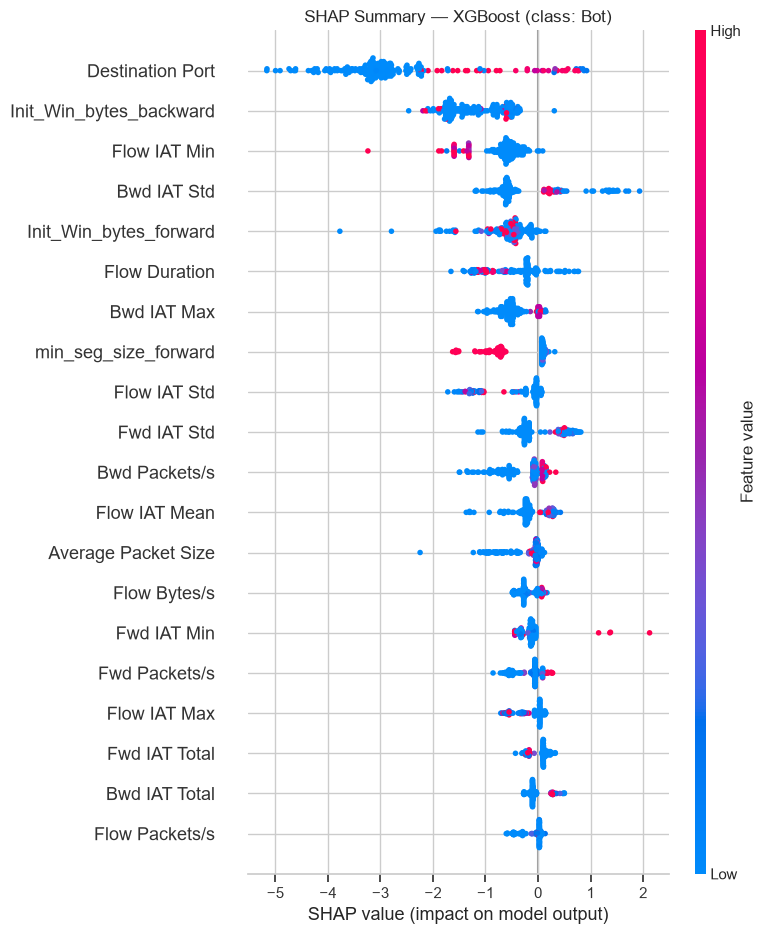

In [10]:
X_test_sample = X_test[:200]

tree_explainer = shap.TreeExplainer(best_ml_model)
shap_values_ml = tree_explainer(X_test_sample)

if shap_values_ml.values.ndim == 3:
    class_shap_values = shap_values_ml.values[:, :, SHAP_CLASS_IDX]
else:
    class_shap_values = shap_values_ml.values

shap.summary_plot(class_shap_values, X_test_sample, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary — {best_ml_name} (class: {class_names[SHAP_CLASS_IDX]})")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "shap_summary_best_ml.png"), dpi=150, bbox_inches="tight")
plt.show()


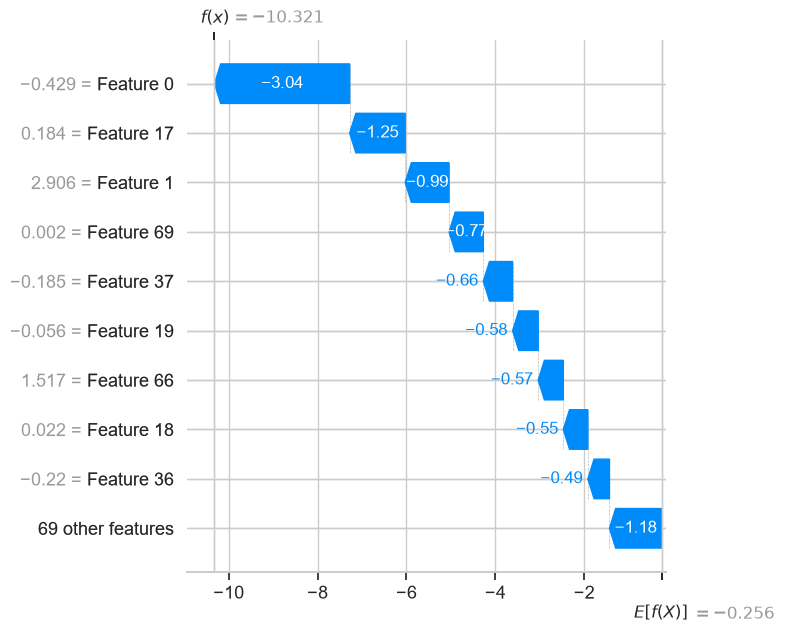

In [11]:
if shap_values_ml.values.ndim == 3:
    single_explanation = shap_values_ml[0, :, SHAP_CLASS_IDX]
else:
    single_explanation = shap_values_ml[0]

shap.plots.waterfall(single_explanation, show=False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "shap_waterfall_best_ml.png"), dpi=150, bbox_inches="tight")
plt.show()


## SHAP — Best DL Model

In [ ]:
background = X_train_res[np.random.choice(X_train_res.shape[0], 50, replace=False)]
X_test_sample_dl = X_test[:50]

def predict_fn(x):
    if best_dl_name == "1D CNN":
        x = x.reshape((x.shape[0], x.shape[1], 1))
    elif best_dl_name == "Autoencoder+MLP":
        x = ae_encoder.predict(x, verbose=0)
    return best_dl_model.predict(x, verbose=0)

kernel_explainer = shap.KernelExplainer(predict_fn, background)
shap_values_dl = kernel_explainer.shap_values(X_test_sample_dl, nsamples=100)

if isinstance(shap_values_dl, list):
    class_shap_values_dl = shap_values_dl[SHAP_CLASS_IDX]
else:
    class_shap_values_dl = shap_values_dl[:, :, SHAP_CLASS_IDX] if shap_values_dl.ndim == 3 else shap_values_dl

shap.summary_plot(class_shap_values_dl, X_test_sample_dl, feature_names=feature_names, show=False)
plt.title(f"SHAP Summary — {best_dl_name} (class: {class_names[SHAP_CLASS_IDX]})")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "shap_summary_best_dl.png"), dpi=150, bbox_inches="tight")
plt.show()


  0%|          | 0/50 [00:00<?, ?it/s]

In [ ]:
expected_value = kernel_explainer.expected_value
expected_value = expected_value[SHAP_CLASS_IDX] if isinstance(expected_value, (list, np.ndarray)) else expected_value

waterfall_explanation = shap.Explanation(
    values=class_shap_values_dl[0], base_values=expected_value,
    data=X_test_sample_dl[0], feature_names=feature_names,
)
shap.plots.waterfall(waterfall_explanation, show=False)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "shap_waterfall_best_dl.png"), dpi=150, bbox_inches="tight")
plt.show()


## Final Summary

In [ ]:
print("=== FINAL COMPARISON ===")
display(results_df)
print(f"\nBest ML model: {best_ml_name}")
print(f"Best DL model: {best_dl_name}")
print(f"\nAll plots saved to: {PLOTS_DIR}/")
print(f"Comparison table saved to: {os.path.join(RESULTS_DIR, 'comparison_table.csv')}")
